# 06 : Matplotlib

강의자료: `docs/course/06_Matplotlib.md`

목적에 맞는 그래프를 고르는 연습.

| 목적 | 그래프 |
| --- | --- |
| 분포 | Histogram, Density |
| 관계 | Scatter |
| 비교 | Bar, Box |
| 추세 | Line |

## 데이터

URL에서 바로 읽는다. 내려받아 둘 필요가 없다.

- `drinks.csv` — 193개국 주류 소비량
- `ufo.csv` — UFO 목격 기록 80,543건

출처: `https://github.com/justmarkham/DAT8`

저장 위치는 `outputs/figures/`.

In [1]:
import matplotlib.pyplot as plt
import setuptools                # Python 3.12에서 distutils가 빠져 필요한 shim
import koreanize_matplotlib      # 한글 폰트 등록 — import만 하면 적용된다
import numpy as np
import pandas as pd
from pathlib import Path

FIG = Path("outputs/figures")
FIG.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
print("준비 완료")

준비 완료


## 1. 데이터 불러오기

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/drinks.csv"
drink_cols = ["country", "beer", "spirit", "wine", "pure", "continent"]

# na_filter=False — 대륙 'NA'(북미)가 결측치로 읽히는 것을 막는다
drinks = pd.read_csv(url, header=0, names=drink_cols, na_filter=False)

print(drinks.shape)
print(drinks["continent"].value_counts())
drinks.head()

(193, 6)
continent
AF    53
EU    45
AS    44
NA    23
OC    16
SA    12
Name: count, dtype: int64


,country,beer,spirit,wine,pure,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF


## 2. Histogram — 분포

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/437597223.py:6: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/437597223.py:6: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/437597223.py:6: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/437597223.py:6: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/437597223.py:6: UserWarning: Glyph 47589 (\N{HANGUL SYLLABLE MAEG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_7470

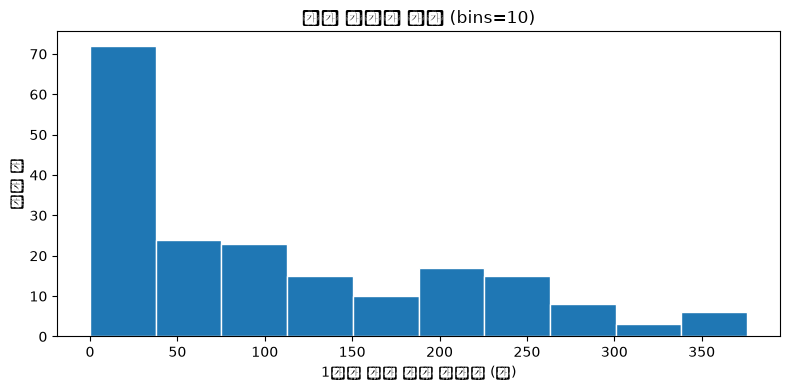

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
drinks["beer"].plot(kind="hist", bins=10, ax=ax, edgecolor="white")
ax.set_title("맥주 소비량 분포 (bins=10)")
ax.set_xlabel("1인당 연간 맥주 소비량 (잔)")
ax.set_ylabel("국가 수")
fig.tight_layout()
fig.savefig(FIG / "1_1.png", dpi=120)
plt.show()

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 47589 (\N{HANGUL SYLLABLE MAEG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/388053490.py:8: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/3880

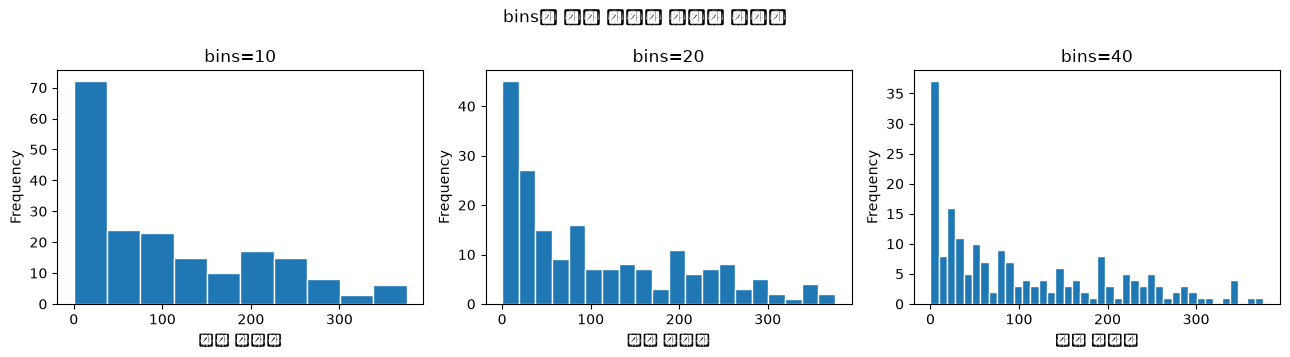

In [4]:
# bins를 늘리면 더 잘게 쪼개 보인다. 너무 잘게 쪼개면 잡음까지 보인다.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, b in zip(axes, [10, 20, 40]):
    drinks["beer"].plot(kind="hist", bins=b, ax=ax, edgecolor="white")
    ax.set_title(f"bins={b}")
    ax.set_xlabel("맥주 소비량")
fig.suptitle("bins에 따라 분포가 다르게 보인다")
fig.tight_layout()
fig.savefig(FIG / "1_3.png", dpi=120)
plt.show()

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1832353078.py:5: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1832353078.py:5: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1832353078.py:5: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1832353078.py:5: UserWarning: Glyph 47589 (\N{HANGUL SYLLABLE MAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1832353078.py:5: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykerne

/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python

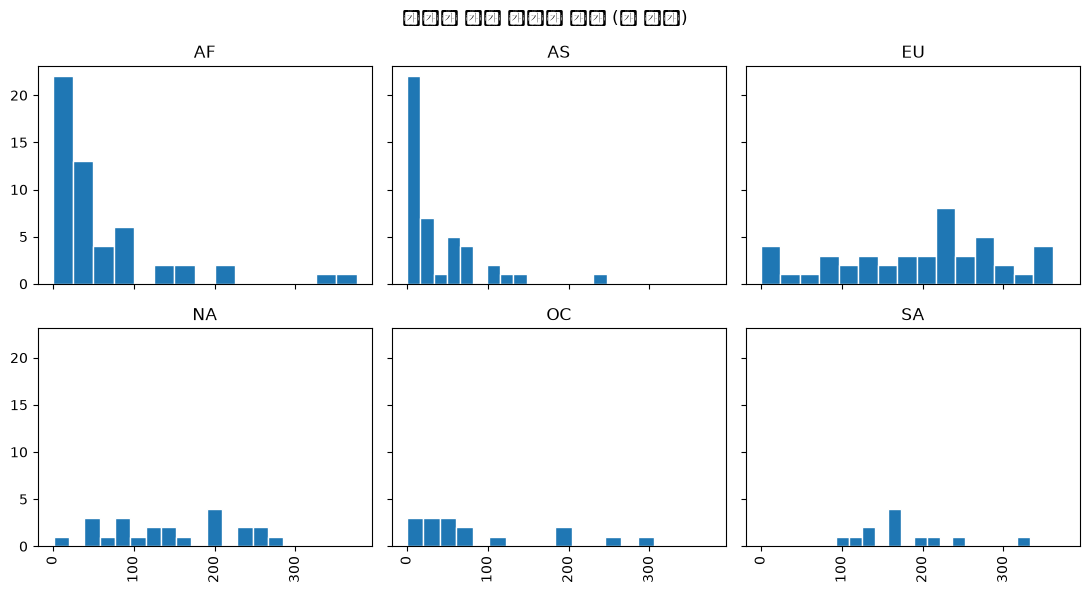

In [5]:
# 대륙별로 나눠 그린다. sharex/sharey로 축을 맞춰야 서로 비교가 된다.
drinks.hist(column="beer", by="continent", figsize=(11, 6),
            layout=(2, 3), sharex=True, sharey=True, bins=15, edgecolor="white")
plt.suptitle("대륙별 맥주 소비량 분포 (축 통일)")
plt.tight_layout()
plt.savefig(FIG / "1_4.png", dpi=120)
plt.show()

## 3. Scatter — 관계

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/755498815.py:6: UserWarning: Glyph 47589 (\N{HANGUL SYLLABLE MAEG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/755498815.py:6: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/755498815.py:6: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/755498815.py:6: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/755498815.py:6: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/755

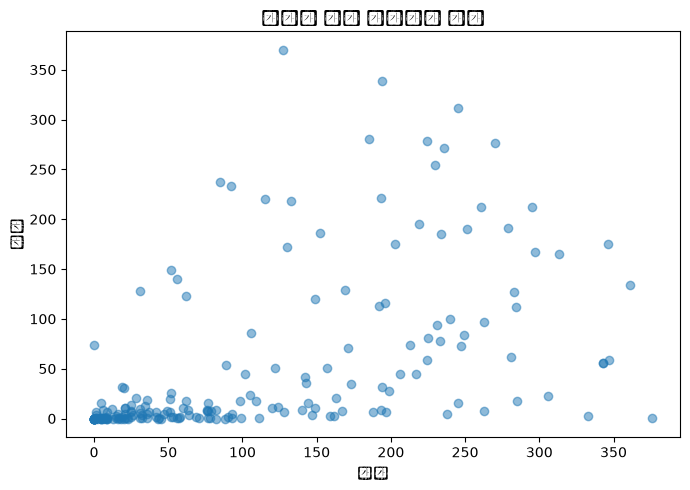

상관계수: 0.527


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(drinks["beer"], drinks["wine"], alpha=0.5)
ax.set_xlabel("맥주")
ax.set_ylabel("와인")
ax.set_title("맥주와 와인 소비량의 관계")
fig.tight_layout()
fig.savefig(FIG / "2_1.png", dpi=120)
plt.show()

print("상관계수:", round(drinks["beer"].corr(drinks["wine"]), 3))

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:10: UserWarning: Glyph 47589 (\N{HANGUL SYLLABLE MAEG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:10: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:10: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:10: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:10: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:10: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:10: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipyke

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:11: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG / "2_3.png", dpi=120)
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:11: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG / "2_3.png", dpi=120)
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1704089682.py:11: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG / "2_3.png", dpi=120)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51613 (\N{HAN

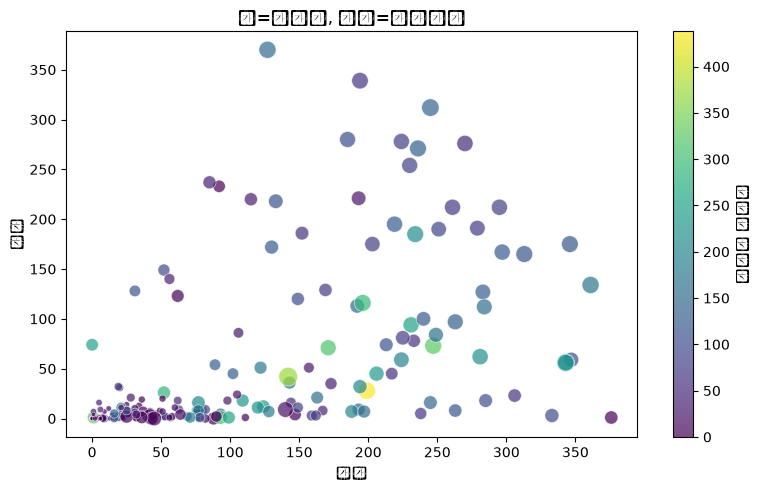

In [7]:
# 세 번째 변수를 색으로 얹는다
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(drinks["beer"], drinks["wine"],
                c=drinks["spirit"], s=drinks["pure"] * 12 + 10,
                cmap="viridis", alpha=0.7, edgecolor="white", linewidth=0.5)
ax.set_xlabel("맥주")
ax.set_ylabel("와인")
ax.set_title("색=증류주, 크기=순알코올")
fig.colorbar(sc, ax=ax, label="증류주 소비량")
fig.tight_layout()
fig.savefig(FIG / "2_3.png", dpi=120)
plt.show()

## 4. Bar — 비교

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipyk

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/1546438941.py:12: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ip

/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python

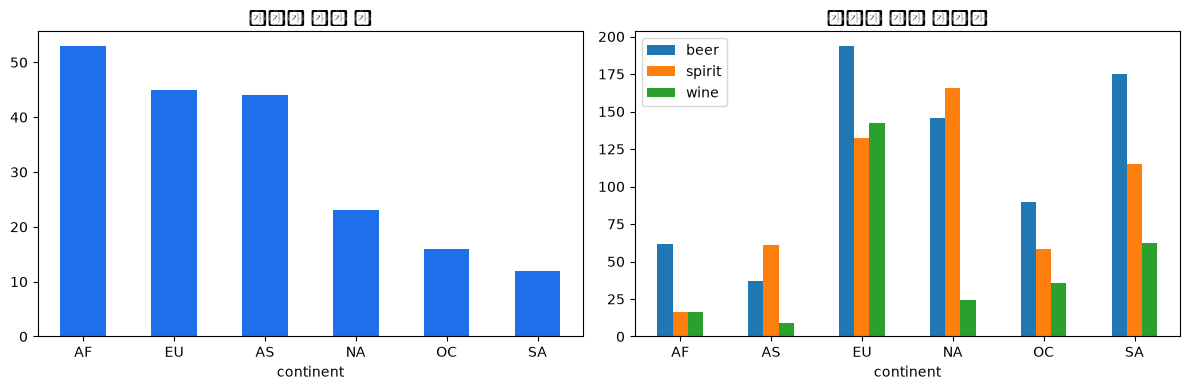

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

drinks["continent"].value_counts().plot(kind="bar", ax=axes[0], color="#1f6feb")
axes[0].set_title("대륙별 국가 수")
axes[0].tick_params(axis="x", rotation=0)

drinks.groupby("continent")[["beer", "spirit", "wine"]].mean().plot(
    kind="bar", ax=axes[1])
axes[1].set_title("대륙별 평균 소비량")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig(FIG / "3_2.png", dpi=120)
plt.show()

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/593739753.py:7: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/

/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/pyt

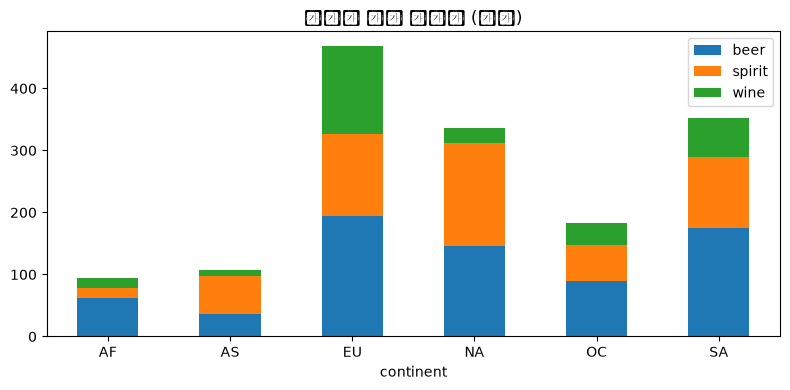

In [9]:
# 누적 막대 — 전체 크기와 구성비를 같이 본다
fig, ax = plt.subplots(figsize=(8, 4))
drinks.groupby("continent")[["beer", "spirit", "wine"]].mean().plot(
    kind="bar", stacked=True, ax=ax)
ax.set_title("대륙별 평균 소비량 (누적)")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG / "3_3.png", dpi=120)
plt.show()

## 5. Box — 분포 비교

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2756748780.py:12: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2756748780.py:12: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2756748780.py:12: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2756748780.py:12: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2756748780.py:12: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipyker

/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.

증류주 5수 요약:
count    193.0
mean      81.0
std       88.3
min        0.0
25%        4.0
50%       56.0
75%      128.0
max      438.0
Name: spirit, dtype: float64


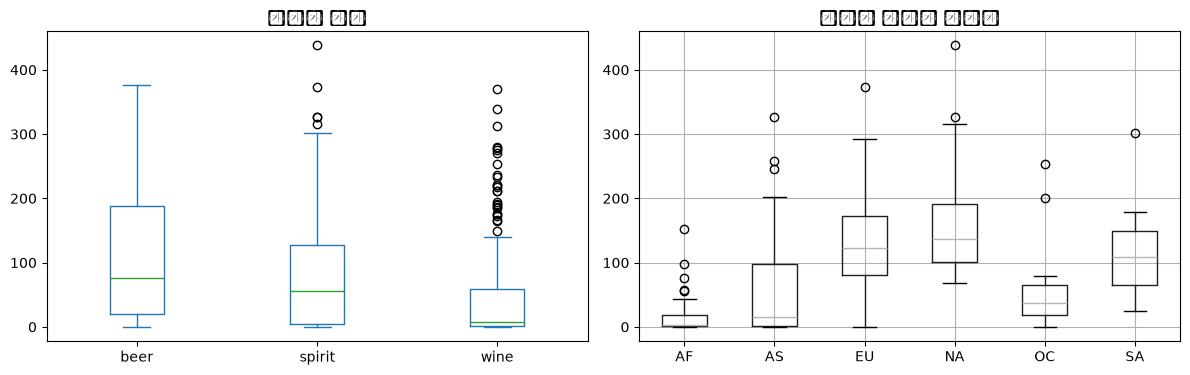

In [10]:
print("증류주 5수 요약:")
print(drinks["spirit"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
drinks[["beer", "spirit", "wine"]].plot(kind="box", ax=axes[0])
axes[0].set_title("주류별 분포")

drinks.boxplot(column="spirit", by="continent", ax=axes[1])
axes[1].set_title("대륙별 증류주 소비량")
axes[1].set_xlabel("")
plt.suptitle("")
fig.tight_layout()
fig.savefig(FIG / "4_3.png", dpi=120)
plt.show()

## 6. Line — 추세

(80543, 5)


/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2951762812.py:15: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2951762812.py:15: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2951762812.py:15: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2951762812.py:15: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2951762812.py:15: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/i

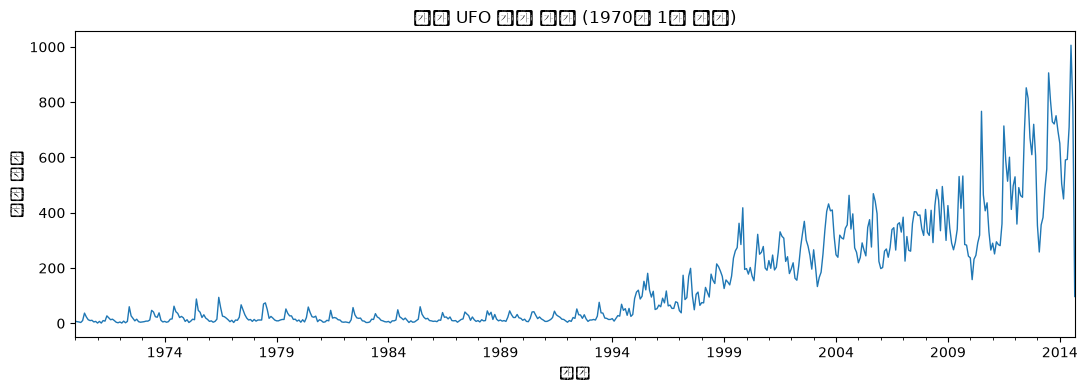

In [11]:
ufo = pd.read_csv("https://raw.githubusercontent.com/justmarkham/DAT8/master/data/ufo.csv")
print(ufo.shape)

ufo["Time"] = pd.to_datetime(ufo["Time"])
ufo["YearMonth"] = ufo["Time"].dt.to_period("M")

recent = ufo[ufo["Time"] >= "1970-01-01"]
monthly = recent.groupby("YearMonth").size()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, linewidth=1)
ax.set_title("월별 UFO 목격 건수 (1970년 1월 이후)")
ax.set_xlabel("연월")
ax.set_ylabel("목격 건수")
fig.tight_layout()
fig.savefig(FIG / "5_1.png", dpi=120)
plt.show()

## 연습 문제

대륙별 와인 평균과 연도별 UFO 목격 추이를 그린다.

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:14: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:14: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:14: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:14: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:14: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/

/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:15: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG / "5_2.png", dpi=120)
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:15: UserWarning: Glyph 47449 (\N{HANGUL SYLLABLE RYUG}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG / "5_2.png", dpi=120)
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:15: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG / "5_2.png", dpi=120)
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:15: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG / "5_2.png", dpi=120)
/var/folders/4_/c8r80mh10bg6c5vt02pzb90m0000gn/T/ipykernel_74707/2983059349.py:15: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu

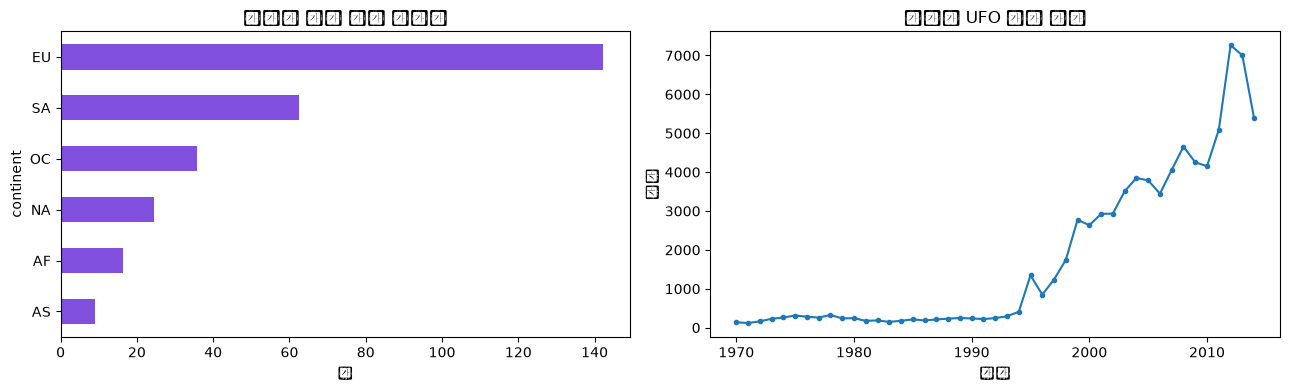

저장된 그림: ['1_1.png', '1_3.png', '1_4.png', '2_1.png', '2_3.png', '3_2.png', '3_3.png', '4_3.png', '5_1.png', '5_2.png']


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

drinks.groupby("continent")["wine"].mean().sort_values().plot(
    kind="barh", ax=axes[0], color="#8250df")
axes[0].set_title("대륙별 평균 와인 소비량")
axes[0].set_xlabel("잔")

yearly = ufo[ufo["Time"] >= "1970-01-01"].groupby(ufo["Time"].dt.year).size()
yearly.plot(ax=axes[1], marker="o", markersize=3)
axes[1].set_title("연도별 UFO 목격 건수")
axes[1].set_xlabel("연도")
axes[1].set_ylabel("건수")

fig.tight_layout()
fig.savefig(FIG / "5_2.png", dpi=120)
plt.show()

print("저장된 그림:", sorted(p.name for p in FIG.glob("*.png")))